# Notebook 08 — IRASA fitting: iEEG (Frauscher 2018)

Decomposes iEEG spectra into aperiodic and periodic components using **IRASA**
(Irregular Resampling Auto-Spectral Analysis; Wen & Liu, 2016).  
Uses identical data loading and Welch settings (2 s segments, 1 s overlap) as NB 02,
enabling direct method comparison in NB 09.

**Frequency range**: 2–40 Hz.  IRASA requires `band[1] * h_max < fs/2` (Nyquist).
With `h_max = 2.0` and `fs = 200 Hz`, the upper band must be < 50 Hz.
Note: specparam (NB 02) was fit on 2–100 Hz; the comparison in NB 09 is therefore
restricted to parameters derived from the same 2–40 Hz range.

**Runtime note**: IRASA resamples at 20 different h-factors — expect 5–15 min.

**Peak memory**: ~3.8 GB (20 h-factors × 1772 × 13600 × float64).

**Outputs** saved to `data/interim/`:
- `irasa_ieeg_results.csv` — long-format (one row per detected peak; NaN if no peaks)
- `irasa_ieeg_ch_summary.csv` — per-channel summary (one row per channel)
- `region_aperiodic_irasa_ieeg.csv` — region-level median exponent/offset

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io

from pesco.irasa import (
    inspect_irasa_fit_quality,
    inspect_irasa_fits,
    irasa2pandas,
    run_irasa,
)

In [ ]:
PROJECT_ROOT = Path("../../").resolve()
print(f"Project root: {PROJECT_ROOT}")

DATA_DIR     = PROJECT_ROOT / "data"
IEEG_MAT     = DATA_DIR / "Frauscher2018" / "WakefulnessMatlabFile.mat"
CHANNEL_INFO = DATA_DIR / "Frauscher2018" / "ChannelInformation.csv"
REGION_INFO  = DATA_DIR / "Frauscher2018" / "RegionInformation.csv"
INTERIM_DIR  = DATA_DIR / "interim"
INTERIM_DIR.mkdir(exist_ok=True)

FS           = 200      # Hz
R2_THRESHOLD = 0.90     # chapter standard

# IRASA constraint: band[1] * h_max < fs/2 (Nyquist = 100 Hz).
# With h_max=2.0: band[1] must be < 50 Hz.  40 * 2.0 = 80 Hz — safe.
# band lower bound 1 Hz: matches specparam fitting range in chapter Methods.
IRASA_SETTINGS = dict(
    band=(1.0, 40.0),
    nperseg=400,          # 2 s @ 200 Hz
    noverlap=200,         # 1 s overlap
    hset_info=(1.05, 2.0, 0.05),
)
PEAK_SETTINGS = dict(
    peak_threshold=2.5,
    min_peak_height=0.0,
    peak_width_limits=(0.5, 12.0),
    smoothing_window=1,
)

## 1. Load iEEG data

Identical loading logic as NB 02.

In [4]:
print(f"Loading {IEEG_MAT.name} …")

try:
    mat = scipy.io.loadmat(str(IEEG_MAT))
    data       = mat["Data"].T
    Fs         = float(np.array(mat["SamplingFrequency"]).flatten()[0])
    ch_regions = np.array(mat["ChannelRegion"]).flatten()
    ch_names   = [str(x[0][0]) for x in mat["ChannelName"]]
    print("Loaded via scipy.io.loadmat")
except Exception as e:
    print(f"scipy.io failed ({e}), trying h5py …")
    with h5py.File(IEEG_MAT, "r") as f:
        data         = np.array(f["Data"]).T
        Fs           = float(np.array(f["SamplingFrequency"]).flatten()[0])
        ch_regions   = np.array(f["ChannelRegion"]).flatten()
        ch_names_refs = np.array(f["ChannelName"]).flatten()
        ch_names = [
            "".join(chr(c) for c in np.array(f[ref]).flatten())
            for ref in ch_names_refs
        ]
    print("Loaded via h5py")

print(f"Data shape : {data.shape}  |  Fs: {Fs} Hz")
print(f"Duration   : {data.shape[1] / Fs:.1f} s  |  Channels: {len(ch_names)}")

Loading WakefulnessMatlabFile.mat …
Loaded via scipy.io.loadmat
Data shape : (1772, 13600)  |  Fs: 200.0 Hz
Duration   : 68.0 s  |  Channels: 1772


## 2. Run IRASA

IRASA separates each spectrum into a fractal (aperiodic) component and an
oscillatory (periodic) component by exploiting the fact that resampling
a signal by a factor h shifts peaks in frequency but leaves the 1/f background
unchanged.  The geometric mean of the up- and down-resampled spectra provides
a peak-free estimate of the aperiodic component.

In [5]:
print(f"Running IRASA on {data.shape[0]} channels …")
print(f"Settings: {IRASA_SETTINGS}")
print("(This may take 5-15 minutes.)")

irasa_result = run_irasa(data, fs=FS, **IRASA_SETTINGS)

print(f"\nFrequencies   : {irasa_result.freqs[0]:.2f} - {irasa_result.freqs[-1]:.2f} Hz  "
      f"({len(irasa_result.freqs)} bins)")
print(f"raw_spectrum  : {irasa_result.raw_spectrum.shape}")
print(f"aperiodic     : {irasa_result.aperiodic.shape}")
print(f"periodic      : {irasa_result.periodic.shape}")

Running IRASA on 1772 channels …
Settings: {'band': (2.0, 40.0), 'nperseg': 400, 'noverlap': 200, 'hset_info': (1.05, 2.0, 0.05)}
(This may take 5–15 minutes.)

Frequencies   : 2.00 – 40.00 Hz  (77 bins)
raw_spectrum  : (1772, 77)
aperiodic     : (1772, 77)
periodic      : (1772, 77)


Quick sanity check — median aperiodic and periodic spectra.

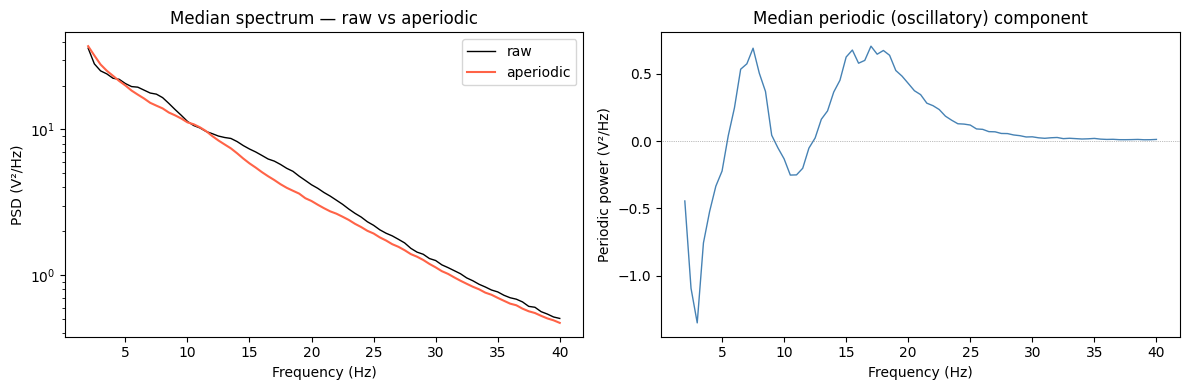

In [6]:
freqs = irasa_result.freqs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(freqs, np.median(irasa_result.raw_spectrum, axis=0),
            label="raw", color="black", linewidth=1)
ax.semilogy(freqs, np.median(irasa_result.aperiodic, axis=0),
            label="aperiodic", color="tomato", linewidth=1.5)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (V²/Hz)")
ax.set_title("Median spectrum — raw vs aperiodic")
ax.legend()

ax = axes[1]
ax.plot(freqs, np.median(irasa_result.periodic, axis=0),
        color="steelblue", linewidth=1)
ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Periodic power (V²/Hz)")
ax.set_title("Median periodic (oscillatory) component")

fig.tight_layout()
plt.show()

## 3. Extract aperiodic parameters and peaks

In [7]:
results_df = irasa2pandas(irasa_result, fit_func="fixed", **PEAK_SETTINGS)
print(f"Shape: {results_df.shape}")
results_df.head()

Shape: (2103, 8)


,offset,exponent,ID,gof_rsquared,error_mae,cf,pw,bw
0,1.632596,1.313716,0,0.811657,0.040192,14.5,5.999556,5.380126
1,1.602145,1.218200,1,0.810169,0.034897,14.5,5.012580,5.267986
2,1.824908,1.227011,2,0.813765,0.034580,14.5,8.966096,5.436959
3,2.191392,1.418127,3,0.770133,0.060242,14.5,32.671355,5.163631
4,1.827961,1.232187,4,0.949316,0.008135,10.5,1.766728,7.657330


## 4. QC: inspect fit quality

IRASA fit quality summary
       exponent  gof_rsquared  error_mae
count  1772.000      1772.000   1772.000
mean      1.696         0.884      0.037
std       0.489         0.100      0.032
min       0.185         0.079      0.000
25%       1.368         0.847      0.013
50%       1.635         0.914      0.027
75%       2.010         0.952      0.051
max       3.720         0.999      0.191

Channels with R² ≥ 0.8: 1500 / 1772 (84.7 %)


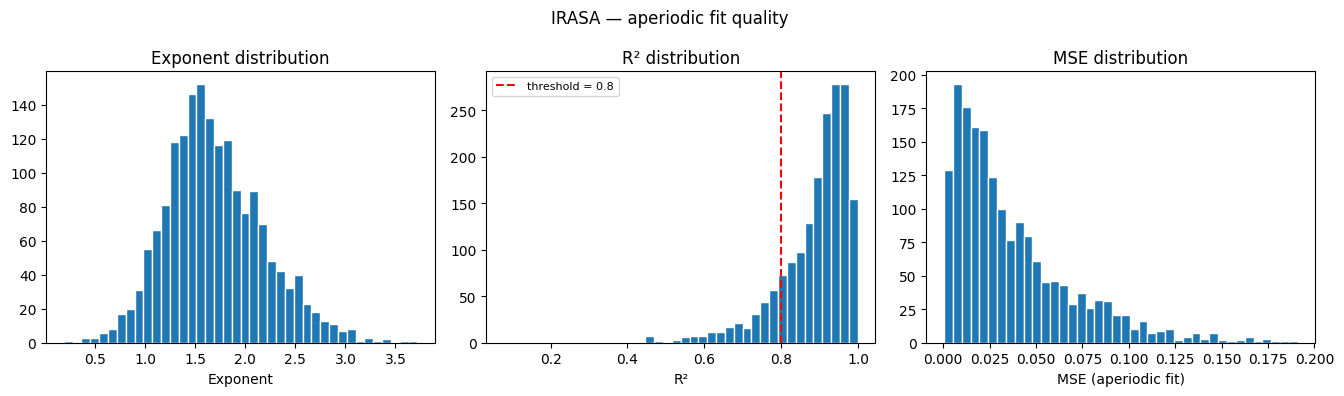

In [8]:
ch_df, summary_df, fig, axes = inspect_irasa_fit_quality(
    results_df, r2_threshold=R2_THRESHOLD, bins=40, show=True
)

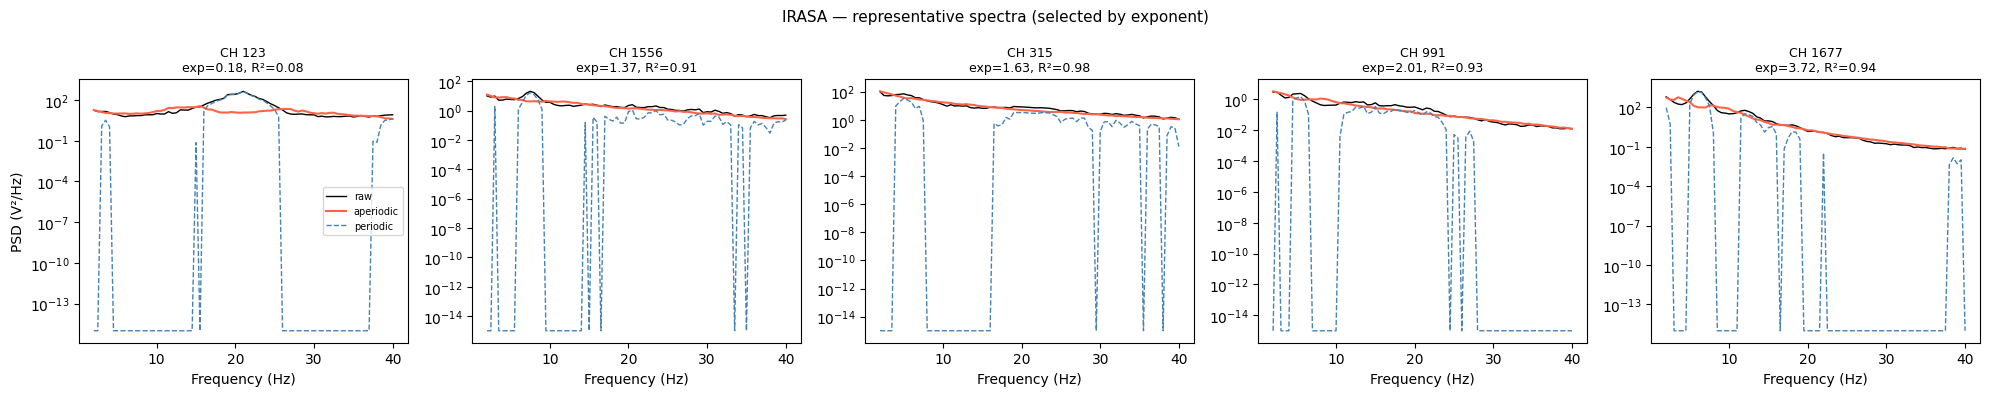

In [9]:
fig, axes = inspect_irasa_fits(
    irasa_result, results_df=results_df, select_by="exponent", n_spectra=5
)

## 5. Attach channel and region metadata

Identical join logic as NB 02.

In [10]:
# Channel metadata
ch_info = pd.read_csv(CHANNEL_INFO)
ch_info.columns = ch_info.columns.str.strip()
for col in ch_info.select_dtypes("object").columns:
    ch_info[col] = ch_info[col].str.strip("'")

# Region labels from the MATLAB file
ch_region_df = pd.DataFrame({
    "ch_name": ch_names,
    "Region":  ch_regions.astype(int),
})

# Region names
region_info = pd.read_csv(REGION_INFO)
region_info.columns = region_info.columns.str.strip()
for col in region_info.select_dtypes("object").columns:
    region_info[col] = region_info[col].str.strip("'")

ch_meta = ch_region_df.merge(region_info, on="Region", how="left")
ch_meta = ch_meta.merge(
    ch_info.rename(columns={"Channel name": "ch_name"}),
    on="ch_name", how="left"
)
ch_meta["ID"] = range(len(ch_meta))

results_full = results_df.merge(ch_meta, on="ID", how="left")
results_full["good_fit"] = results_full["gof_rsquared"] >= R2_THRESHOLD

print(f"Shape: {results_full.shape}")
results_full.head(3)

Shape: (2103, 20)


,offset,exponent,ID,gof_rsquared,error_mae,cf,pw,bw,ch_name,Region_x,Region name,Lobe,Electrode type,Patient,Hemisphere,Region_y,x,y,z,good_fit
0,1.632596,1.313716,0,0.811657,0.040192,14.5,5.999556,5.380126,GD001Lc_11,31,Middle temporal gyrus,Temporal,D,1.0,L,31.0,60.127504,-34.113299,-3.886026,True
1,1.602145,1.218200,1,0.810169,0.034897,14.5,5.012580,5.267986,GD001Lc_12,31,Middle temporal gyrus,Temporal,D,1.0,L,31.0,63.792560,-34.067332,-3.726989,True
2,1.824908,1.227011,2,0.813765,0.034580,14.5,8.966096,5.436959,GD001Lc_13,31,Middle temporal gyrus,Temporal,D,1.0,L,31.0,67.457616,-34.021428,-3.567995,True


## 6. Regional summary

In [11]:
ch_summary = results_full.drop_duplicates(subset="ID").drop(
    columns=["cf", "pw", "bw"], errors="ignore"
)

if "Lobe" in ch_summary.columns:
    print("Good fits by lobe:")
    print(
        ch_summary[ch_summary["good_fit"]]
        .groupby("Lobe")["exponent"]
        .agg(["count", "median"])
        .round(3)
    )

Good fits by lobe:
           count  median
Lobe                    
Frontal      667   1.502
Insula        89   1.737
Occipital     86   2.178
Parietal     285   1.711
Temporal     373   1.945


In [13]:
def region_summary_irasa(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate channel-level IRASA results to region level (median)."""
    good = df[df["good_fit"]].copy()
    good = good.dropna(subset=["Region name", "exponent", "offset"])
    grp = good.groupby(["Region name", "Lobe"], as_index=False)
    return grp.agg(
        exponent_median=("exponent", "median"),
        exponent_iqr=("exponent", lambda x: x.quantile(0.75) - x.quantile(0.25)),
        exponent_n=("exponent", "count"),
        offset_median=("offset", "median"),
        offset_iqr=("offset", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )


irasa_region = region_summary_irasa(ch_summary)
print(irasa_region.sort_values("exponent_median", ascending=False).to_string(index=False))

                                 Region name      Lobe  exponent_median  exponent_iqr  exponent_n  offset_median  offset_iqr
  Inferior ocipital gyrus and occipital pole Occipital         2.326629      0.371872          22       3.610473    0.610503
  Lingual gyrus and occipital fusiform gyrus Occipital         2.286268      0.673947          21       3.760402    0.454895
          Superior and middle occipital gyri Occipital         2.258257      0.768404          19       3.382040    0.949770
           Fusiform and parahippocampal gyri  Temporal         2.128156      0.363313          44       3.412349    1.495083
                                      Cuneus Occipital         2.083645      0.154237          13       3.890569    1.053704
             Temporal pole and planum polare  Temporal         1.996838      0.761125          22       2.797587    1.535851
                     Inferior temporal gyrus  Temporal         1.992958      0.598212          36       3.070713    1.109445


## 7. Save results

In [ ]:
# Long-format (one row per peak) — _1_40hz suffix to distinguish from old 2-40 Hz run
out_path = INTERIM_DIR / "irasa_ieeg_results_1_40hz.csv"
results_full.to_csv(out_path, index=False)
print(f"Saved {len(results_full)} rows → {out_path}")

# Per-channel summary
ch_summary.to_csv(INTERIM_DIR / "irasa_ieeg_ch_summary_1_40hz.csv", index=False)
print(f"Saved channel summary ({len(ch_summary)} rows) → "
      f"{INTERIM_DIR / 'irasa_ieeg_ch_summary_1_40hz.csv'}")

# Region-level medians
irasa_region.to_csv(INTERIM_DIR / "region_aperiodic_irasa_ieeg_1_40hz.csv", index=False)
print(f"Saved region summary ({len(irasa_region)} regions) → "
      f"{INTERIM_DIR / 'region_aperiodic_irasa_ieeg_1_40hz.csv'}")